LGBM & XGBM

In [1]:
import pandas as pd
import numpy as np

In [2]:
df=pd.read_csv('diabetes.csv')

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.shape

(768, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='object')

In [7]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [8]:
cols_to_update = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
df[cols_to_update] = df[cols_to_update].replace(0, np.nan)

In [9]:
df.fillna(df.median(), inplace=True)

In [10]:
df.to_csv('cleaned_diabetes.csv',index=False)

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
df.corr(numeric_only=True)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
Glucose,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BloodPressure,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
SkinThickness,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
Insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
DiabetesPedigreeFunction,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
Age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
Outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


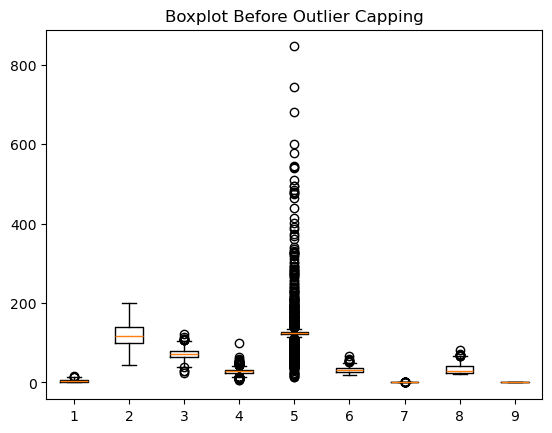

In [13]:
import matplotlib.pyplot as plt
plt.boxplot(df)
plt.title("Boxplot Before Outlier Capping")
plt.show()

In [14]:
def outlier_capping(df, column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    IQR = q3 - q1
    lower_extreme = q1 - 1.5 * IQR
    upper_extreme = q3 + 1.5 * IQR
    df[column] = df[column].apply(lambda x: lower_extreme if x < lower_extreme 
                                  else upper_extreme if x > upper_extreme else x)

for col in df.select_dtypes(['int', 'float']):
    outlier_capping(df, col)

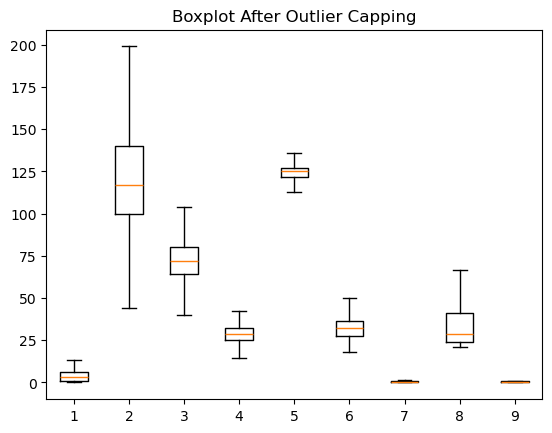

In [15]:
plt.boxplot(df)
plt.title("Boxplot After Outlier Capping")
plt.show()

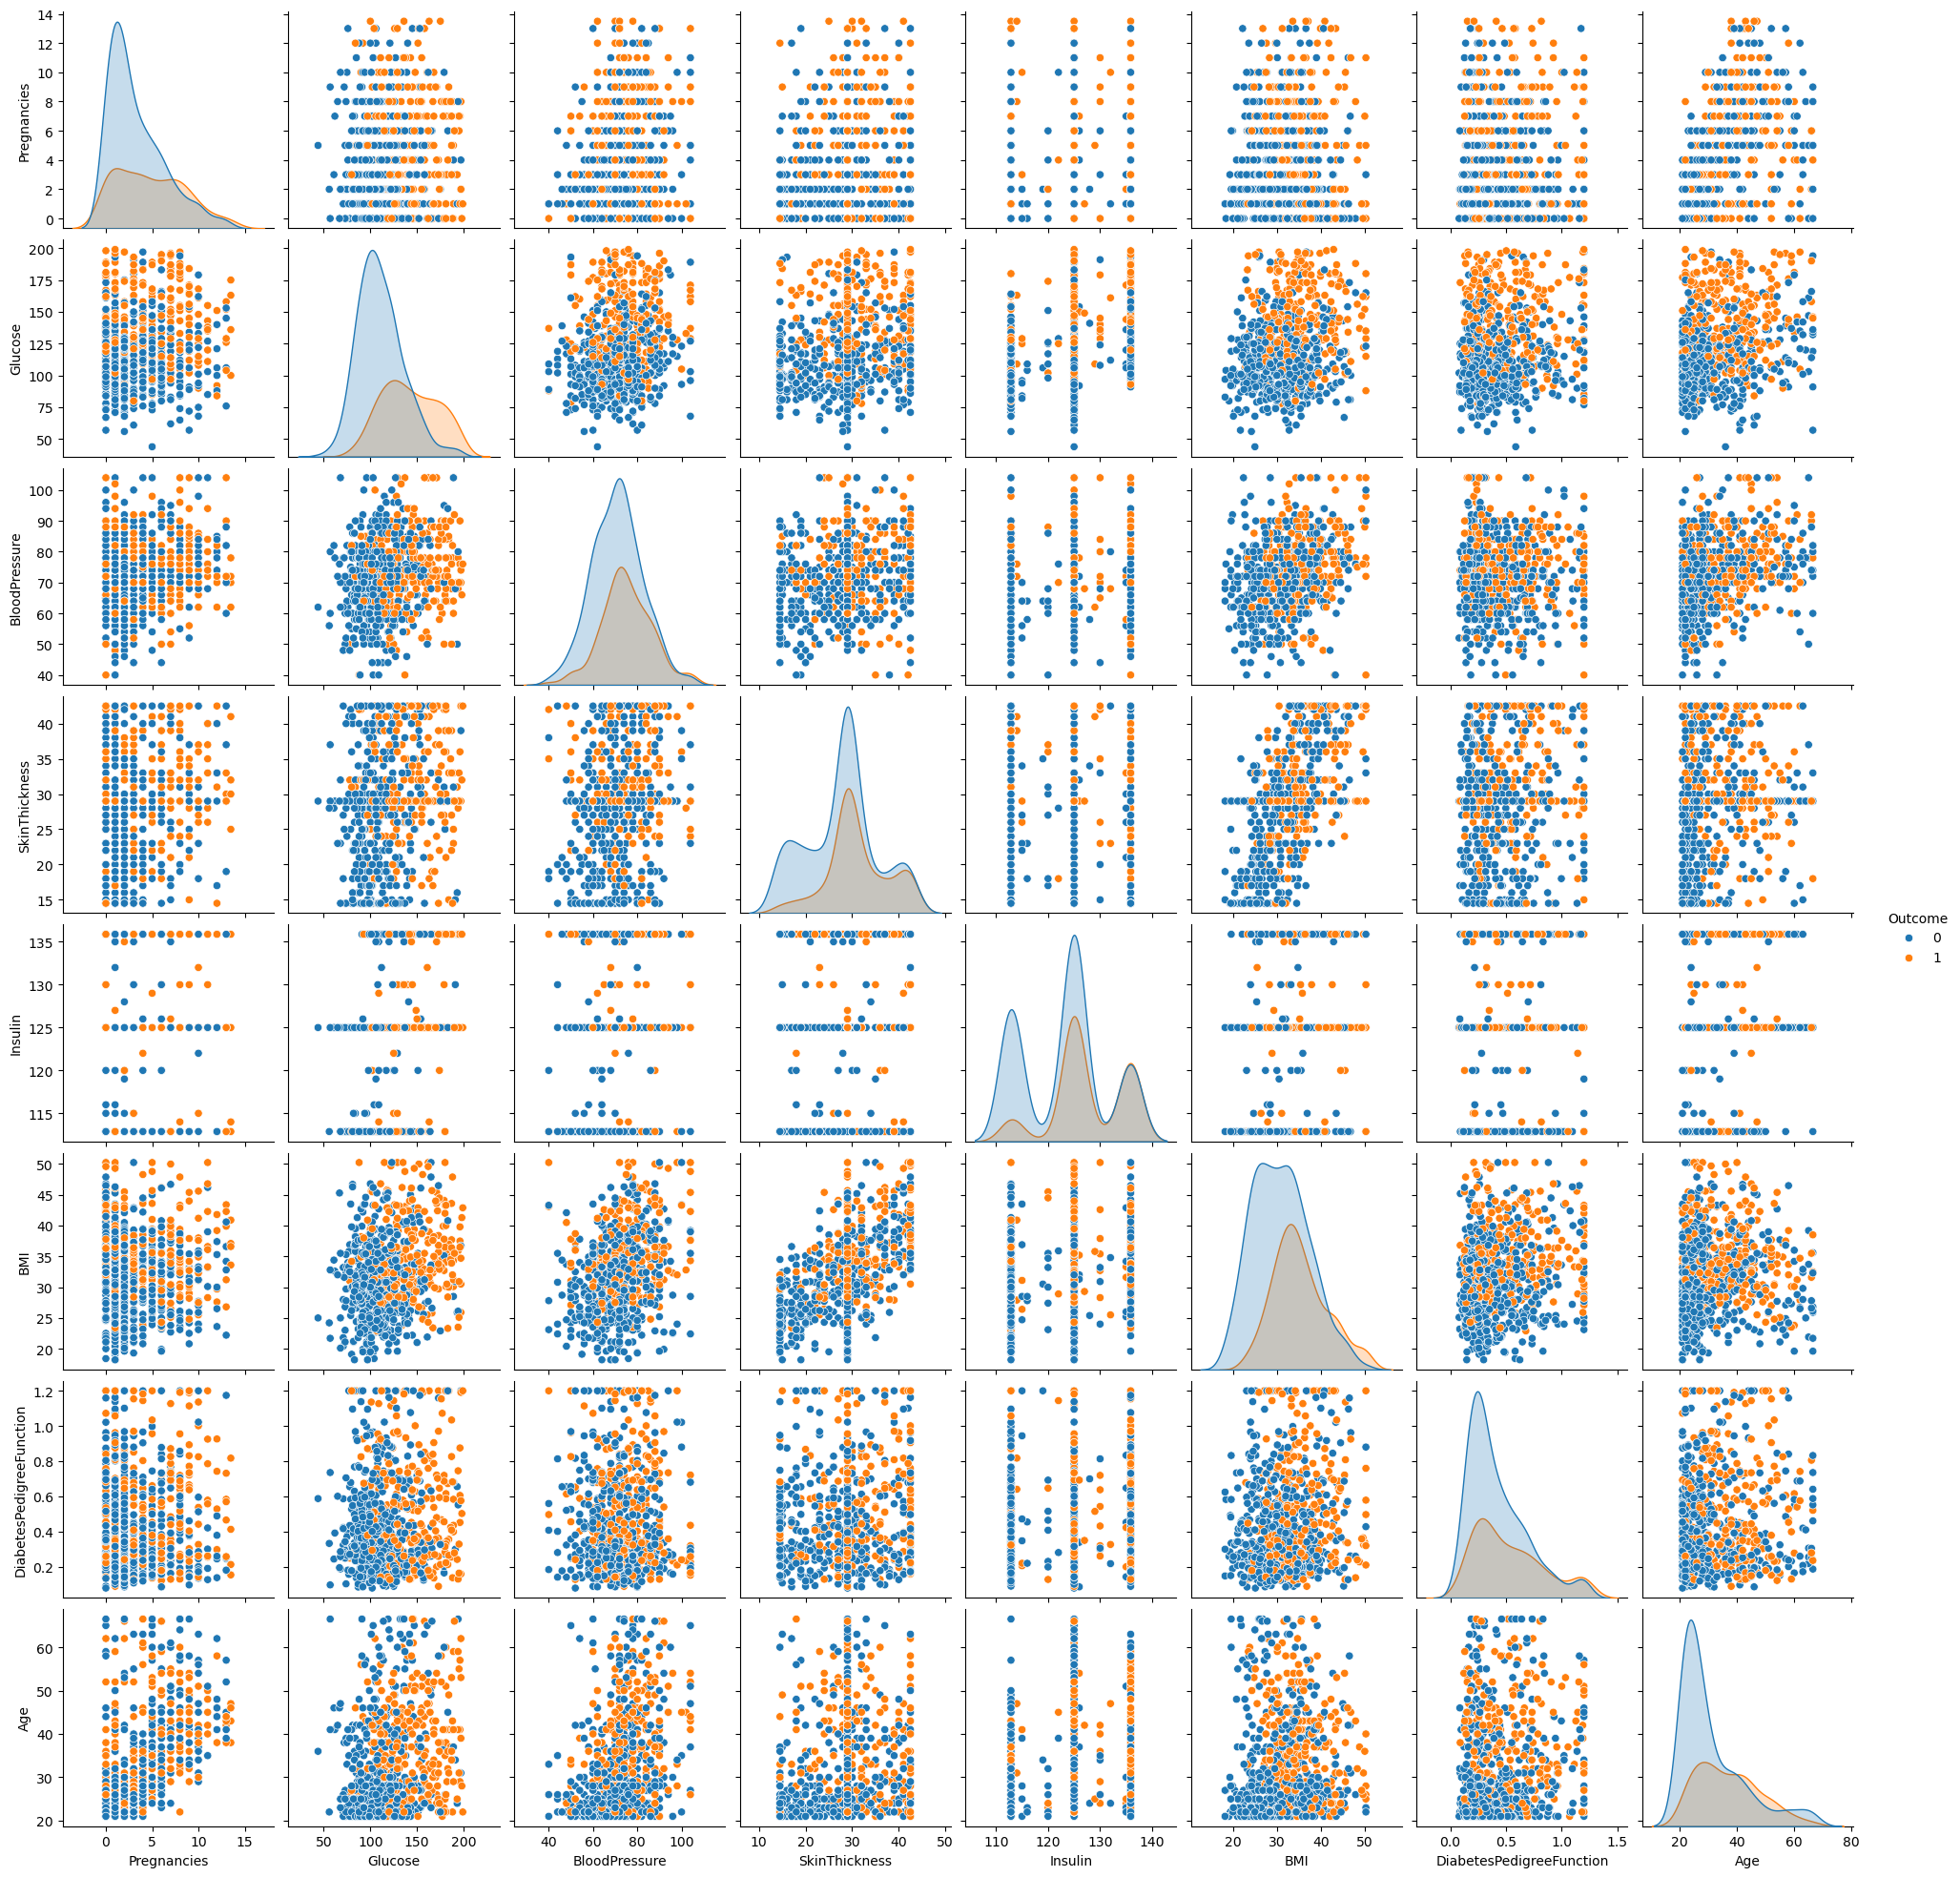

In [16]:
import seaborn as sns
sns.pairplot(df, hue="Outcome")
plt.show()

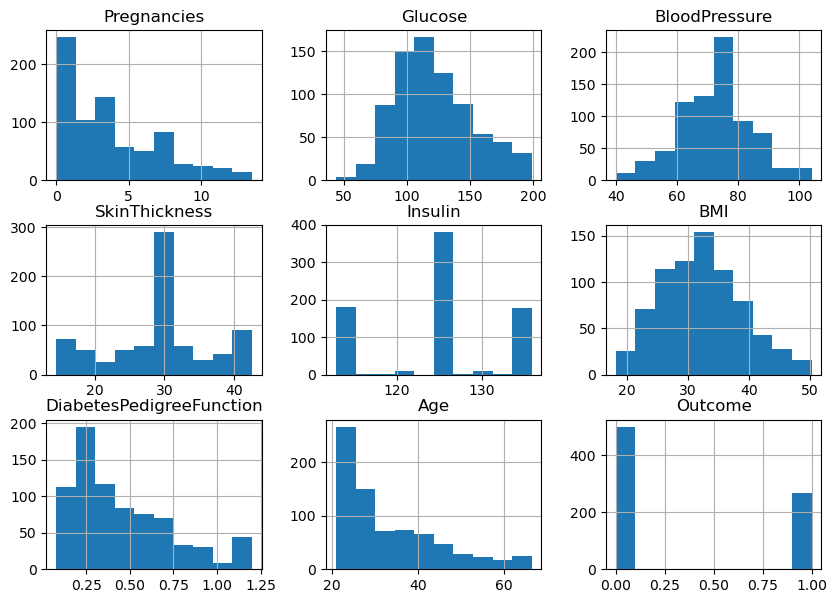

In [17]:
df.hist(figsize=(10,7))
plt.show()

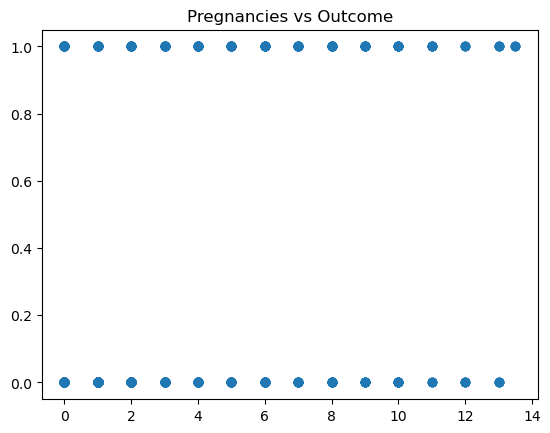

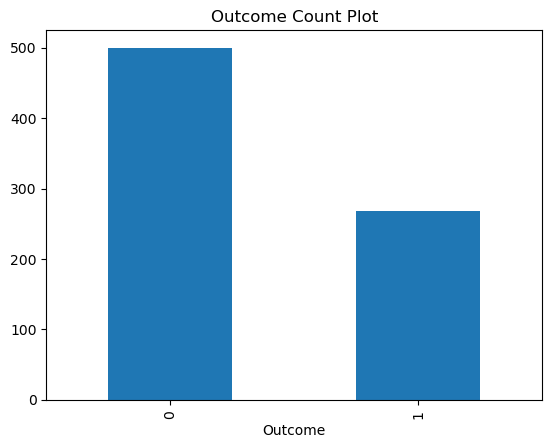

In [18]:
plt.scatter(df['Pregnancies'], df['Outcome'])
plt.title("Pregnancies vs Outcome")
plt.show()
df['Outcome'].value_counts().plot(kind='bar')
plt.title("Outcome Count Plot")
plt.show()

# Building Predictive Models

In [19]:
target = df[['Outcome']]
features = df.drop(columns=['Outcome'])
target

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [20]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(features, target, test_size=0.2, random_state=42)

print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(614, 8) (154, 8)
(614, 1) (154, 1)


# XG Boost Alogrithms

In [21]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(eval_metric='logloss')
xgb_model.fit(x_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [22]:
y_test_pred_xgb = xgb_model.predict(x_test)

from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
print("\nXGBOOST Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_xgb))
print(classification_report(y_test, y_test_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_xgb))


XGBOOST Model Evaluation:
Accuracy: 0.7272727272727273
              precision    recall  f1-score   support

           0       0.82      0.74      0.78        99
           1       0.60      0.71      0.65        55

    accuracy                           0.73       154
   macro avg       0.71      0.72      0.71       154
weighted avg       0.74      0.73      0.73       154

Confusion Matrix:
[[73 26]
 [16 39]]


# LGBM Classifier Algorithm

In [23]:
pip install lightgbm

Note: you may need to restart the kernel to use updated packages.


In [24]:
from lightgbm import LGBMClassifier
lgb_model = LGBMClassifier()
lgb_model.fit(x_train, y_train)

C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:93: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
C:\Users\DELL\anaconda3\Lib\site-packages\sklearn\preprocessing\_label.py:129: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, dtype=self.classes_.dtype, warn=True)


[LightGBM] [Info] Number of positive: 213, number of negative: 401
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000106 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 572
[LightGBM] [Info] Number of data points in the train set: 614, number of used features: 8
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.346906 -> initscore=-0.632669
[LightGBM] [Info] Start training from score -0.632669
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


LGBMClassifier()

In [25]:
y_test_pred_lgb = lgb_model.predict(x_test)
print("\nLightGBM Model Evaluation:")
print("Accuracy:", accuracy_score(y_test, y_test_pred_lgb))
print(classification_report(y_test, y_test_pred_lgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_test_pred_lgb))


LightGBM Model Evaluation:
Accuracy: 0.7207792207792207
              precision    recall  f1-score   support

           0       0.80      0.75      0.77        99
           1       0.60      0.67      0.63        55

    accuracy                           0.72       154
   macro avg       0.70      0.71      0.70       154
weighted avg       0.73      0.72      0.72       154

Confusion Matrix:
[[74 25]
 [18 37]]


# Comparative Analysis

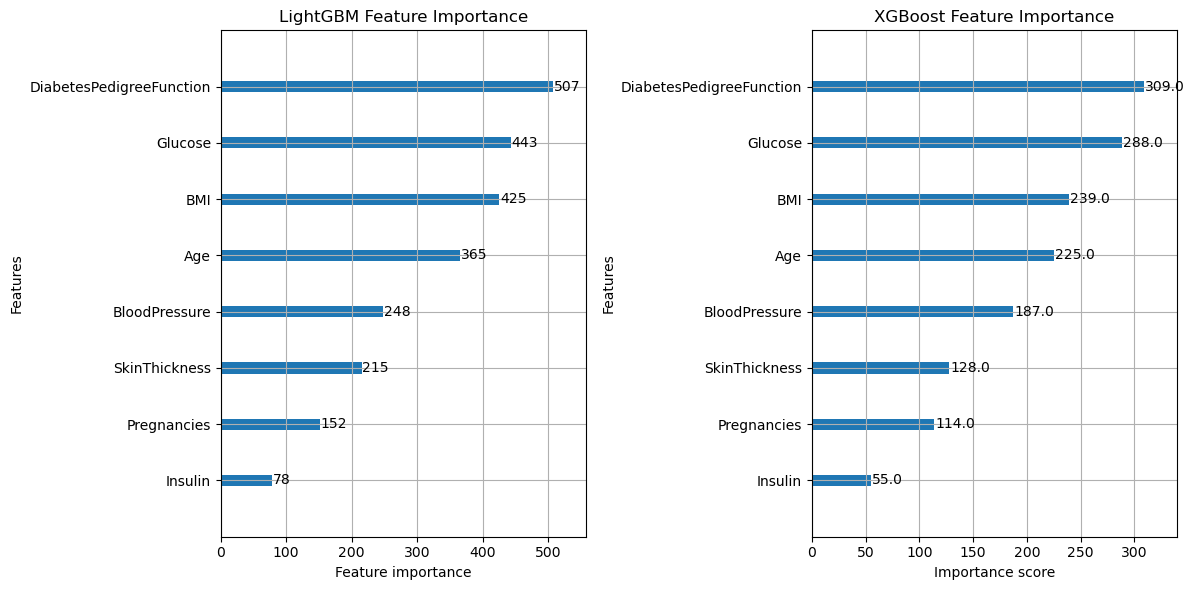

In [26]:
import lightgbm as lgb
import xgboost as xgb
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

lgb.plot_importance(lgb_model, ax=ax[0])
ax[0].set_title("LightGBM Feature Importance")

xgb.plot_importance(xgb_model, ax=ax[1])
ax[1].set_title("XGBoost Feature Importance")

plt.tight_layout()
plt.show()

Conclusion
Both XGBoost and LightGBM are powerful boosting algorithms.
XGBoost provides better control and is more stable.
LightGBM is faster and works well with large datasets.
In this dataset:
[Write which model got better accuracy]
LightGBM is faster but XGBoost may give slightly better accuracy.
Practical Use
Use LightGBM for large-scale data (fast training).
Use XGBoost for better accuracy and control.